In [ ]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
from typing import TypedDict

class AgentState(TypedDict):
    query: str
    symptoms: str
    exercise_candidates: str
    result: str

In [ ]:
# LLM 초기화
llm = Ollama(model="exaone3.5:2.4b")

C:\Users\campus4D010\AppData\Local\Temp\ipykernel_16568\1318451510.py:2: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  llm = Ollama(model="exaone3.5:2.4b")  # Ollama 모델 로딩


In [ ]:
# 에이전트 함수 및 프롬프트 정의

# [추출 에이전트] 증상 추출
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 신체적 상태나 증상에 해당하는 단어 또는 구를 추출하세요.
결과는 쉼표로 구분된 문자열로 출력하세요.

질문: {query}
""")

def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm
    symptoms = chain.invoke({"query": state["query"]})

    return {**state, "symptoms": symptoms.content.strip() if hasattr(symptoms, 'content') else symptoms.strip()}


# [후보 에이전트] 맞춤 운동 리스트 추출
matcher_prompt = PromptTemplate.from_template("""
다음 사용자의 상태(증상)를 해결하거나 개선하는 데 도움이 되는 운동 3가지를 추천하세요.
결과는 운동 이름만 쉼표로 구분하여 출력하세요.

상태/증상: {symptoms}
""")

def matcher_agent(state: AgentState):
    chain = matcher_prompt | llm
    candidates = chain.invoke({"symptoms": state["symptoms"]})
    return {**state, "exercise_candidates": candidates.content.strip() if hasattr(candidates, 'content') else candidates.strip()}


# [답변 생성 에이전트] 최종 답변 생성 (개조식 출력 조건)
answer_prompt = PromptTemplate.from_template("""
사용자의 상태와 추천 운동 리스트를 바탕으로 최종 답변을 작성하세요.

[상태]: {symptoms}
[추천 운동]: {exercise_candidates}
""")

def answer_agent(state: AgentState):
    chain = answer_prompt | llm
    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_candidates": state["exercise_candidates"]
    })
    return {**state, "result": answer.content.strip() if hasattr(answer, 'content') else answer.strip()}

# LangGraph 정의 및 연결
workflow = StateGraph(AgentState)

workflow.add_node("extractor", extractor_agent)
workflow.add_node("matcher", matcher_agent)
workflow.add_node("answer", answer_agent)

workflow.set_entry_point("extractor")
workflow.add_edge("extractor", "matcher")
workflow.add_edge("matcher", "answer")
workflow.add_edge("answer", END)

# 컴파일
app = workflow.compile()

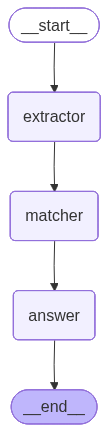

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# 사용자 질문
query = "체력이 안좋고, 살이 계속 찌는데 어떤 운동을 할까?"
# 실행
result = app.invoke({"query": query})

print("============================== 최종 응답:")
print(result["result"])  # 결과 출력

============================== 최종 응답:
## 당신의 건강 상태와 운동 추천에 대한 답변

체력이 떨어지고 체중 증가가 지속되는 상황에서는 단기간에 큰 변화를 기대하기보다는 **지속 가능한 습관 형성**에 초점을 맞추는 것이 중요합니다. 

**HIIT**는 짧지만 강렬한 운동으로 효율적인 칼로리 소모를 통해 체중 감소와 근력 증진에 도움이 됩니다. 특히 체력 저하 상태에서는 **처음에는 고강도 세션 수를 줄이고 gradually** 증가시키는 것이 부상 위험을 줄이는 데 좋습니다.

**요가**는 유연성 향상, 근력 강화, 스트레스 감소에 탁월합니다. 특히 **요가 자세 연습**은 자세 교정에도 도움이 되어 건강한 생활 습관 형성에 기여합니다.

**가벼운 조깅**은 지속 가능한 유산소 운동으로, 일주일에 3~4회 정도 **꾸준하게** 실천하면 체력 향상과 심폐 기능 강화에 효과적입니다. 조깅 시간을 점차 늘려나가면서 본인의 체력 수준에 맞춰 조절하는 것이 중요합니다.

**추가 팁:**

* **전문가 상담:** 개인의 건강 상태에 따라 의사나 트레이너와 상담 후 운동 계획을 수립하는 것이 안전하고 효과적입니다.
* **균형 잡힌 식단:** 운동과 병행하여 균형 잡힌 식단을 유지하는 것이 필수입니다. 가공식품 섭취를 줄이고, 신선한 과일, 채소, 단백질 위주로 식단을 구성하세요.
* **휴식과 스트레스 관리:** 충분한 수면과 휴식을 취하고 스트레스를 관리하는 것도 건강 증진에 중요합니다.

꾸준한 노력과 전문가의 도움을 통해 건강하고 활기찬 삶을 되찾으시길 응원합니다!
